# MRI Brain Tumor Classification — VGG16-NADE Hybrid

**Dataset:** [Brain Tumor MRI Dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)  
**Classes:** `glioma` | `meningioma` | `notumor` | `pituitary`  
**Architecture:** VGG16 (ImageNet backbone) + NADE (Neural Autoregressive Distribution Estimator)

---

## 0. Setup

In [ ]:
pip install tensorflow
pip install pydot

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys, os
# Add project root to path
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from src.utils import set_seed, configure_gpu, print_env_info, ensure_dirs

set_seed(42)
configure_gpu()
ensure_dirs()
print_env_info()

  Python      : 3.11.15
  TensorFlow  : 2.21.0
  Keras       : 3.13.2
  GPUs        : 0  ([])


## 1. Download Dataset

Requires `~/.kaggle/kaggle.json`. Get your credentials at https://www.kaggle.com/settings.

In [4]:
from src.utils import download_dataset

# Uncomment to download:
# download_dataset()

## 2. Dataset Exploration

In [5]:
import config
from src.data_preprocessing import print_dataset_stats

print_dataset_stats()


────────────────────────────────────────
  TRAIN — /Users/vedantrajput/Desktop/mri_tumor_classifier/data/raw/Training
────────────────────────────────────────
  glioma         :  1400 images
  meningioma     :  1400 images
  notumor        :  1400 images
  pituitary      :  1400 images
  TOTAL          :  5600 images

────────────────────────────────────────
  TEST — /Users/vedantrajput/Desktop/mri_tumor_classifier/data/raw/Testing
────────────────────────────────────────
  glioma         :   400 images
  meningioma     :   400 images
  notumor        :   400 images
  pituitary      :   400 images
  TOTAL          :  1600 images


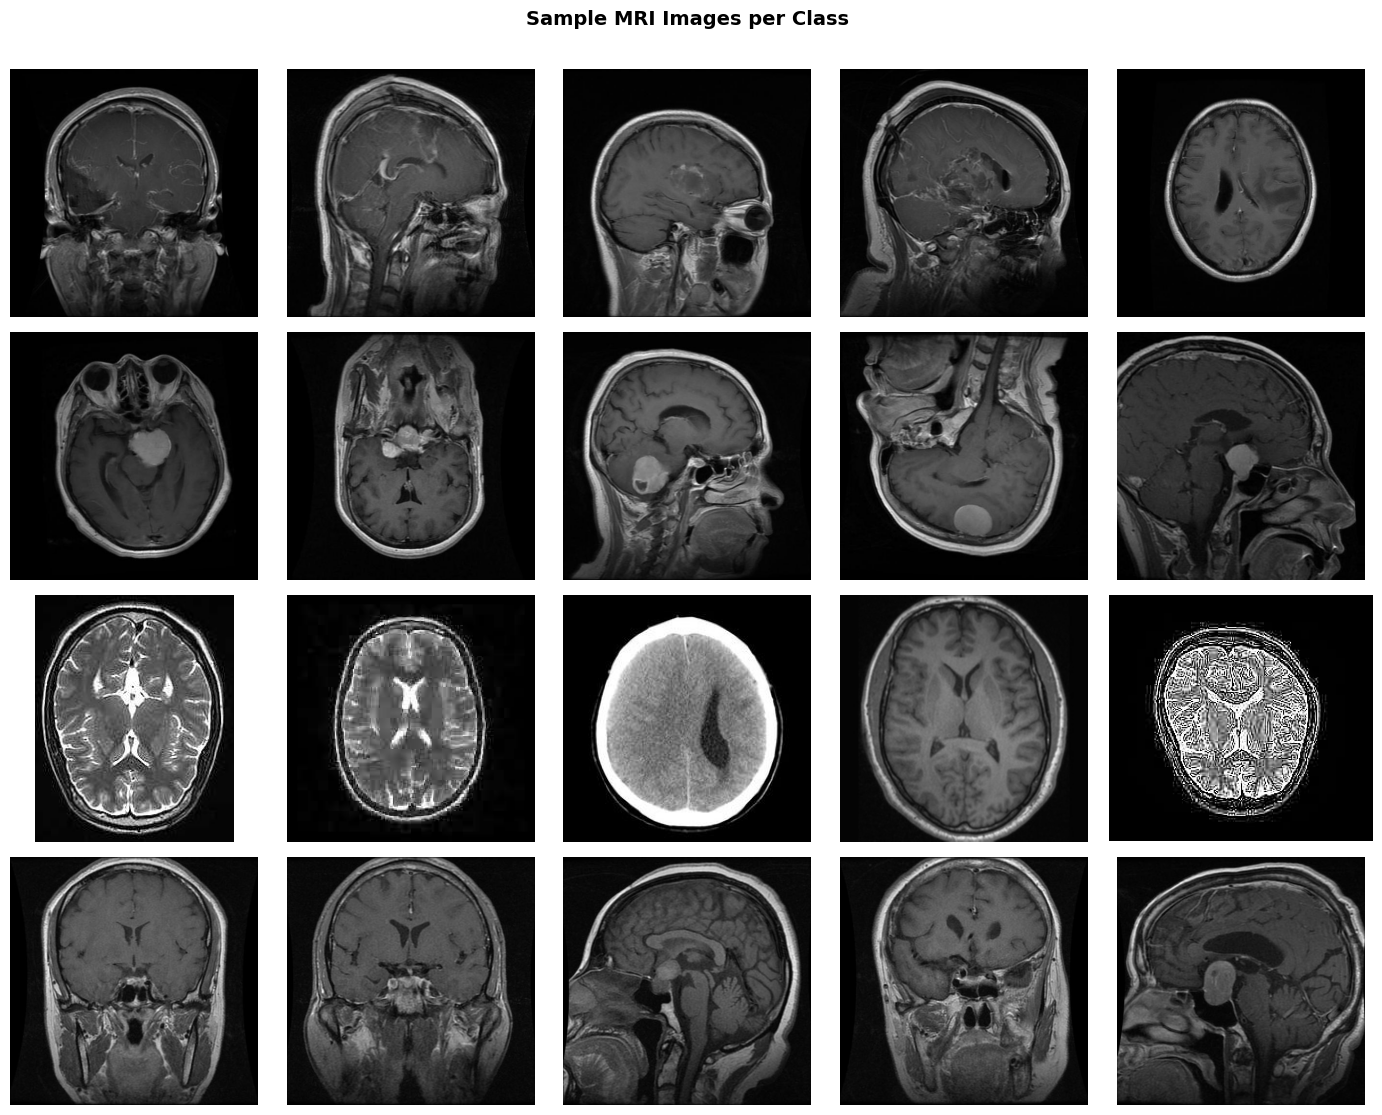

In [6]:
from pathlib import Path
import cv2

fig, axes = plt.subplots(4, 5, figsize=(14, 11))
for row, cls in enumerate(config.CLASS_NAMES):
    cls_dir = Path(config.TRAIN_DIR) / cls
    imgs = sorted(cls_dir.glob('*.jpg'))[:5]
    for col, img_path in enumerate(imgs):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=11, fontweight='bold')

plt.suptitle('Sample MRI Images per Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

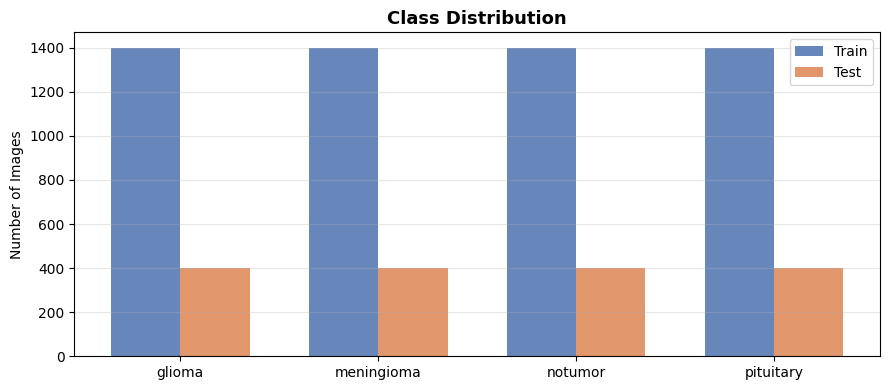

In [7]:
# Class distribution bar chart
counts = {}
for split, d in [('Train', config.TRAIN_DIR), ('Test', config.TEST_DIR)]:
    for cls in config.CLASS_NAMES:
        p = Path(d) / cls
        counts[f'{split}_{cls}'] = len(list(p.glob('*'))) if p.exists() else 0

df = pd.DataFrame({
    'Class': config.CLASS_NAMES * 2,
    'Count': [counts.get(f'Train_{c}', 0) for c in config.CLASS_NAMES] +
             [counts.get(f'Test_{c}', 0)  for c in config.CLASS_NAMES],
    'Split': ['Train'] * 4 + ['Test'] * 4,
})

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(4)
w = 0.35
for i, (split, color) in enumerate([('Train', '#4C72B0'), ('Test', '#DD8452')]):
    vals = df[df.Split == split]['Count'].values
    ax.bar(x + i*w, vals, w, label=split, color=color, alpha=0.85)

ax.set_xticks(x + w/2)
ax.set_xticklabels(config.CLASS_NAMES)
ax.set_ylabel('Number of Images')
ax.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Build Data Generators

In [8]:
from src.data_preprocessing import build_generators, compute_class_weights

train_gen, val_gen, test_gen = build_generators()
class_weights = compute_class_weights(train_gen)
print('Class weights:', class_weights)

Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


INFO | Generators ready — train: 4760, val: 840, test: 1600
INFO | Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


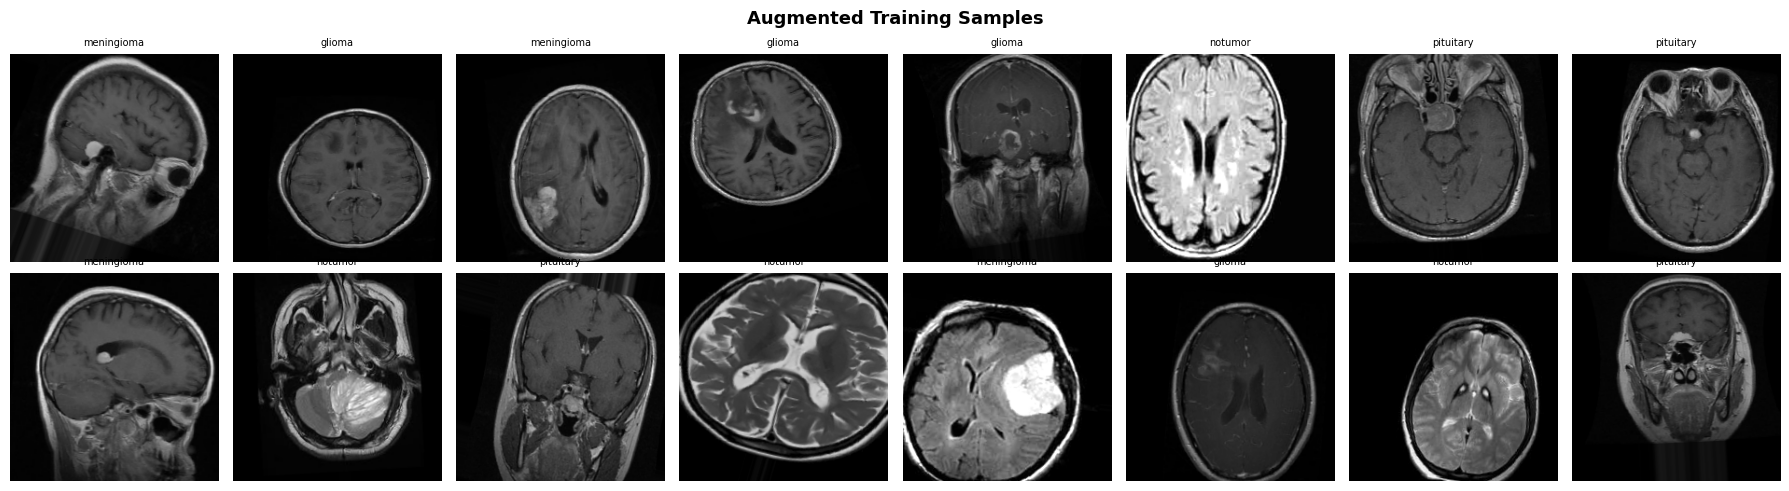

In [9]:
# Visualise augmented training samples
batch_imgs, batch_labels = next(train_gen)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i in range(16):
    img = batch_imgs[i].copy()
    # Undo VGG16 preprocessing
    img[..., 0] += 103.939; img[..., 1] += 116.779; img[..., 2] += 123.68
    img = np.clip(img, 0, 255).astype(np.uint8)
    img = img[..., ::-1]  # BGR → RGB
    cls = config.CLASS_NAMES[batch_labels[i].argmax()]
    ax = axes[i // 8, i % 8]
    ax.imshow(img)
    ax.set_title(cls, fontsize=7)
    ax.axis('off')

plt.suptitle('Augmented Training Samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Build and Inspect the VGG16-NADE Model

In [10]:
from src.model import build_vgg16_nade_model, print_model_summary

model = build_vgg16_nade_model()
print_model_summary(model)

INFO | VGG16 loaded — 19 layers (all frozen)
INFO | Model built — total params: 16,262,852


Model: "VGG16_NADE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ mri_input (InputLayer)      │ (None, 224, 224, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ vgg16 (Functional)          │ (None, 7, 7, 512)       │     14,714,688 │ mri_input[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ gap                         │ (None, 512)             │              0 │ vgg16[0][0]             │
│ (GlobalAveragePooling2D)    │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ feat_proj                   │ (None, 512)             │        264,704 │ gap[0][0]               │
│ (FeatureProjection)         │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ nade (NADELayer)            │ (None, 256)             │      1,051,648 │ feat_proj[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ nade_residual (Concatenate) │ (None, 768)             │              0 │ feat_proj[0][0],        │
│                             │                         │                │ nade[0][0]              │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ fc1 (Dense)                 │ (None, 256)             │        196,864 │ nade_residual[0][0]     │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ bn1 (BatchNormalization)    │ (None, 256)             │          1,024 │ fc1[0][0]               │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ drop1 (Dropout)             │ (None, 256)             │              0 │ bn1[0][0]               │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ fc2 (Dense)                 │ (None, 128)             │         32,896 │ drop1[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ bn2 (BatchNormalization)    │ (None, 128)             │            512 │ fc2[0][0]               │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ drop2 (Dropout)             │ (None, 128)             │              0 │ bn2[0][0]               │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ predictions (Dense)         │ (None, 4)               │            516 │ drop2[0][0]             │
└─────────────────────────────┴─────────────────────────┴────────────────┴─────────────────────────┘

 Total params: 16,262,852 (62.04 MB)

 Trainable params: 1,546,372 (5.90 MB)

 Non-trainable params: 14,716,480 (56.14 MB)


  Trainable params     :    1,546,372
  Non-trainable params :   14,716,480
  Total params         :   16,262,852



In [11]:
# Visualise VGG16 architecture
tf.keras.utils.plot_model(
    model,
    to_file='../results/plots/model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    dpi=80,
)
from IPython.display import Image
Image('../results/plots/model_architecture.png')

You must install pydot (`pip install pydot`) for `plot_model` to work.


FileNotFoundError: No such file or directory: '../results/plots/model_architecture.png'

FileNotFoundError: No such file or directory: '../results/plots/model_architecture.png'

<IPython.core.display.Image object>

## 5. Train — Phase 1 (Frozen Backbone)

In [12]:
from src.model import compile_phase1
import config

compile_phase1(model)

callbacks_p1 = [
    tf.keras.callbacks.ModelCheckpoint(
        config.BEST_MODEL_PATH, monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1
    ),
]

history1 = model.fit(
    train_gen,
    epochs=config.EPOCHS_FROZEN,
    validation_data=val_gen,
    callbacks=callbacks_p1,
    class_weight=class_weights,
)

INFO | Phase-1 compiled — LR=0.0001


Epoch 1/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4877 - auc: 0.7338 - loss: 1.4455 - precision: 0.5111 - recall: 0.4161
Epoch 1: val_accuracy improved from None to 0.47024, saving model to /Users/vedantrajput/Desktop/mri_tumor_classifier/models/saved/vgg16_nade_best.keras

Epoch 1: finished saving model to /Users/vedantrajput/Desktop/mri_tumor_classifier/models/saved/vgg16_nade_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 512s 3s/step - accuracy: 0.5910 - auc: 0.8275 - loss: 1.1196 - precision: 0.6287 - recall: 0.5336 - val_accuracy: 0.4702 - val_auc: 0.8018 - val_loss: 1.2221 - val_precision: 1.0000 - val_recall: 0.0012 - learning_rate: 1.0000e-04
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7306 - auc: 0.9185 - loss: 0.7325 - precision: 0.7633 - recall: 0.6916
Epoch 2: val_accuracy improved from 0.47024 to 0.70833, saving model to /Users/vedantrajput/Desktop/mri_tumor_classifier/models/saved/vgg16_nade_best.keras

Epoch 2: finished saving model to /User

## 6. Train — Phase 2 (Fine-tuning)

In [13]:
from src.model import unfreeze_for_finetuning

unfreeze_for_finetuning(model)

callbacks_p2 = [
    tf.keras.callbacks.ModelCheckpoint(
        config.BEST_MODEL_PATH, monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1
    ),
]

history2 = model.fit(
    train_gen,
    epochs=config.EPOCHS_FINETUNE,
    validation_data=val_gen,
    callbacks=callbacks_p2,
    class_weight=class_weights,
)

INFO | Fine-tune: 4 VGG16 layers now trainable (from block5_conv1)
INFO | Fine-tune compiled — LR=1e-05


Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8859 - auc: 0.9813 - loss: 0.3243 - precision: 0.8986 - recall: 0.8748
Epoch 1: val_accuracy improved from None to 0.88452, saving model to /Users/vedantrajput/Desktop/mri_tumor_classifier/models/saved/vgg16_nade_best.keras

Epoch 1: finished saving model to /Users/vedantrajput/Desktop/mri_tumor_classifier/models/saved/vgg16_nade_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 622s 4s/step - accuracy: 0.8914 - auc: 0.9830 - loss: 0.3075 - precision: 0.9027 - recall: 0.8794 - val_accuracy: 0.8845 - val_auc: 0.9808 - val_loss: 0.3200 - val_precision: 0.8948 - val_recall: 0.8810 - learning_rate: 1.0000e-05
Epoch 2/20
 34/149 ━━━━━━━━━━━━━━━━━━━━ 7:14 4s/step - accuracy: 0.9051 - auc: 0.9854 - loss: 0.2817 - precision: 0.9172 - recall: 0.8946

KeyboardInterrupt: 

## 7. Training Curves

In [14]:
def merge(h1, h2):
    return {k: h1[k] + h2.get(k, []) for k in h1}

history = merge(history1.history, history2.history)
epochs  = range(1, len(history['accuracy']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, (tr, va, title) in zip(axes, [
    ('accuracy', 'val_accuracy', 'Accuracy'),
    ('loss',     'val_loss',     'Loss'),
    ('auc',      'val_auc',      'AUC'),
]):
    ax.plot(epochs, history[tr], lw=2, label='Train')
    if va in history:
        ax.plot(epochs, history[va], lw=2, ls='--', label='Validation')
    # Mark phase boundary
    ax.axvline(config.EPOCHS_FROZEN, color='gray', ls=':', label='Fine-tune start')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('VGG16-NADE Training History', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/plots/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'history1' is not defined

## 8. Evaluation

In [15]:
from src.evaluate import evaluate

report = evaluate(model_path=config.BEST_MODEL_PATH)

ValueError: File not found: filepath=/Users/vedantrajput/Desktop/mri_tumor_classifier/models/saved/vgg16_nade_best.keras. Please ensure the file is an accessible `.keras` zip file.

## 9. Single-Image Inference with MC-Dropout Uncertainty

In [16]:
from src.predict import predict_single, visualise_prediction

# Replace with the path to any MRI image:
TEST_IMAGE = f'{config.TEST_DIR}/glioma/Te-gl_0010.jpg'

result = predict_single(TEST_IMAGE, mc_samples=30)
print('\nPrediction result:')
for k, v in result.items():
    print(f'  {k:<20}: {v}')

visualise_prediction(result, TEST_IMAGE, save_path='../results/plots/sample_prediction.png')

from IPython.display import Image
Image('../results/plots/sample_prediction.png')

ValueError: File not found: filepath=/Users/vedantrajput/Desktop/mri_tumor_classifier/models/saved/vgg16_nade_best.keras. Please ensure the file is an accessible `.keras` zip file.

## 10. Grad-CAM Visualisation

In [17]:
from src.evaluate import plot_grad_cam_gallery, load_model

loaded_model = load_model(config.BEST_MODEL_PATH)
_, _, test_gen_eval = build_generators(batch_size=16)
plot_grad_cam_gallery(loaded_model, test_gen_eval, n_samples=8)

from IPython.display import Image
Image('../results/plots/grad_cam_gallery.png')

ValueError: File not found: filepath=/Users/vedantrajput/Desktop/mri_tumor_classifier/models/saved/vgg16_nade_best.keras. Please ensure the file is an accessible `.keras` zip file.

---
## Summary

| Component | Detail |
|---|---|
| Backbone | VGG16 pretrained on ImageNet |
| Custom module | NADE (Neural Autoregressive Distribution Estimator) |
| Training | Two-phase: frozen backbone → fine-tune block5 |
| Regularisation | Dropout, BatchNorm, NADE density loss, class weights |
| Uncertainty | Monte Carlo Dropout at inference |
| Explainability | Grad-CAM on block5_conv3 |